## Molecular Dynamics (MD) Simulation on MMP-1 Protein-Ligand Complex

If *assets/1cgl_fixed.pdb* does not exist, run this cell once to fix and prepare *1cgl_no_lig.pdb* for MD.

In [1]:
from pdbfixer import PDBFixer
from openmm.app import PDBFile
import os

def fix_protein_pdb(input_pdb: str, output_pdb: str, ph: float = 7.0) -> None:
    fixer = PDBFixer(filename=input_pdb)

    # 1. Identify missing residues
    fixer.findMissingResidues()

    # 2. Replace non-standard residues (e.g. MSE -> MET)
    fixer.findNonstandardResidues()
    fixer.replaceNonstandardResidues()

    # 3. Remove waters / small molecules already in the crystal file
    fixer.removeHeterogens(keepWater=False)

    # 4. Add missing heavy atoms
    fixer.findMissingAtoms()
    fixer.addMissingAtoms(seed=0)

    # 5. Add missing hydrogens
    fixer.addMissingHydrogens(ph)

    os.makedirs(os.path.dirname(output_pdb) if os.path.dirname(output_pdb) else '.', exist_ok=True)
    with open(output_pdb, 'w') as f:
        PDBFile.writeFile(fixer.topology, fixer.positions, f, keepIds=True)

    print(f"Fixed PDB written to: {output_pdb}")

fix_protein_pdb(
    input_pdb  = 'assets/1cgl_no_lig.pdb',
    output_pdb = 'assets/1cgl_fixed.pdb',
    ph         = 7.0,
)

Fixed PDB written to: assets/1cgl_fixed.pdb


## 1. Defining the ChemicalSystem

`ChemicalSystems` are OpenFE containers which define the various components which exist in a system of interest. 
Here, we will be passing the `SmallMoleculeComponent` for each ligand being tested, a `ProteinComponent` generated from our 1cgl.pdb file. The system is created in a vacuum. 

In [2]:
import openfe
from openfe import ChemicalSystem, ProteinComponent, SmallMoleculeComponent
from openff.units import unit

LIGAND_FILES = [
    'assets/ligand_raw_0.sdf',    # our control ligand
    'assets/ligand_raw_2.sdf',
    'assets/ligand_raw_8.sdf',
    'assets/ligand_raw_9.sdf',
]

ligands = [SmallMoleculeComponent.from_sdf_file(f) for f in LIGAND_FILES]
protein = ProteinComponent.from_pdb_file('assets/1cgl_fixed.pdb', name='1cgl_fixed')
systems = [
    ChemicalSystem(
        {'ligand': lig, 'protein': protein},
        name=f"{lig.name}_{protein.name}"
    )
    for lig in ligands
]
for s in systems:
    print(s.name)


[16:16:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


0ED_1cgl_fixed
3342298_1cgl_fixed
71749231_1cgl_fixed
9552079_1cgl_fixed


## 2. Defining the MD simulation settings

There are various different parameters which can be set to determine how the MD simulation will take place. To allow for maximum user flexibility, these are defined as a series of settings objects which control the following:

| **Setting**                    | **Description**                                                |
|:------------------------------|:-----------------------------------------------------------|
| `simulation_settings`        |  Parameters controlling the simulation plan, including the number of `minimization_steps`, the length of the NVT and NPT equilibration (`equilibration_length_nvt` and `equilibration_length`), and the length of the production MD run (`production_length`). |
| `output_settings`        | Parameters controlling the output from the MD simulations, including file names to save the system after minimization, NVT and NPT equilibration, and production run. Special `output_indices` can be defined to select which portions of the system should be saved (default: `not water`). A `trajectory_write_interval` determines the frequency of writing frames to the output trajectory. |
|  `forcefield_settings` | Settings that define the forcefield for the components, including the general `forcefields`, the `small_molecule_forcefield`, the `nonbonded_method`, and the `nonbonded_cutoff`.  |
| `engine_settings`  | Parameters determining how the OpenMM engine will execute the simulation. This controls the `compute_platform` which will be used to carry out the simulation.  |
| `integrator_settings`  |  Parameters controlling the LangevinSplittingDynamicsMove integrator used for simulation, as well as the `barostat_frequency`. |
| `partial_charge_settings`  | Settings that define which method is used for assigning partial charges.  |
|  `protocol_repeats` |  Defines how often to run the MD protocol. |
| `solvation_settings`  | Parameters to control the `solvent_model` and the `solvent_padding`.  |
|  `thermo_settings` |  Parameters to control e.g. the `temperature` and the `pressure` of the system. |

The easiest way to access and change settings is by first importing the default settings, printing them and then changing the settings according to the user's needs.

In [3]:
from openfe.protocols.openmm_md.plain_md_methods import PlainMDProtocol
from openff.units import unit

settings = PlainMDProtocol.default_settings()    # simulated in vacuum to reduce runtime (still 30-60 min)
settings.simulation_settings.equilibration_length_nvt = 0.001 * unit.nanosecond    # skip NVT to reduce runtime
settings.simulation_settings.equilibration_length     = 0.001 * unit.nanosecond    # skip NPT to reduce runtime
settings.simulation_settings.production_length = 1.0 * unit.nanosecond    # long enough to output meaningful RMSD plot
settings.output_settings.trajectory_write_interval = 10 * unit.picosecond
settings.output_settings.checkpoint_interval       = 1.0 * unit.nanosecond
settings.engine_settings.compute_platform = 'CPU'    # change to GPU if possible, should run must faster
settings.thermo_settings.temperature = 310 * unit.kelvin  # set to physiological temperature (37°C)
settings.forcefield_settings.nonbonded_method = 'CutoffNonPeriodic'    # here to allow to work in vacuum
settings.forcefield_settings.nonbonded_cutoff = 1.2 * unit.nanometer

In [4]:
settings

{'engine_settings': {'compute_platform': 'CPU', 'gpu_device_index': None},
 'forcefield_settings': {'constraints': 'hbonds',
                         'forcefields': ['amber/ff14SB.xml',
                                         'amber/tip3p_standard.xml',
                                         'amber/tip3p_HFE_multivalent.xml',
                                         'amber/phosaa10.xml',
                                         'amber/lipid17_merged.xml'],
                         'hydrogen_mass': 3.0,
                         'nonbonded_cutoff': {'unit': 'nanometer', 'val': 1.2},
                         'nonbonded_method': 'CutoffNonPeriodic',
                         'rigid_water': True,
                         'small_molecule_forcefield': 'openff-2.2.1'},
 'integrator_settings': {'barostat': 'MonteCarloBarostat',
                         'barostat_frequency': {'unit': 'timestep',
                                                'val': 25.0},
                         'constraint_

## 3.  Creating a `Protocol`

The actual simulation is performed by a [`Protocol`](https://docs.openfree.energy/en/stable/guide/models/execution.html#protocols-and-the-execution-model). 

With the `Settings` inspected and adjusted, we can provide these to the `Protocol`. Here, the OpenMM-based MD Protocol is named `PlainMDProtocol`.

In [5]:
# Creating the Protocol
from openfe.protocols.openmm_md.plain_md_methods import PlainMDProtocol    # default
protocol = PlainMDProtocol(settings=settings)

## 4. Creating the `NonTransformation`
Once we have the `ChemicalSystem`s, and the `Protocol`, we can create the `NonTransformation`. `NonTransformation` here simply means that the system is not "transformed" between two end states as is the case in binding free energy calculations.

In [6]:
# One NonTransformation per ligand
nontransformations = [
    openfe.NonTransformation(
        system=s,
        protocol=protocol,
        name=s.name,
    )
    for s in systems
]

## 5. Running the MD simulation
Execute this MD simulation using the OpenFE command-line interface (CLI) (run in your terminal).

We'll write out the transformation to disk, so that it can be run using the `openfe quickrun` command:

In [7]:
import pathlib

md_dir = pathlib.Path('md_input')
md_dir.mkdir(exist_ok=True)

for nt in nontransformations:
    out_path = md_dir / f'{nt.name}.json'
    nt.to_json(out_path)
    print(f'Written: {out_path}')

print()
print('Run each simulation from the terminal with (copy and paste):')
for nt in nontransformations:
    print(f'  openfe quickrun md_input/{nt.name}.json '
          f'-o md_results/{nt.name}_results.json '
          f'-d md_results/{nt.name}')


Written: md_input/0ED_1cgl_fixed.json
Written: md_input/3342298_1cgl_fixed.json
Written: md_input/71749231_1cgl_fixed.json
Written: md_input/9552079_1cgl_fixed.json

Run each simulation from the terminal with (copy and paste):
  openfe quickrun md_input/0ED_1cgl_fixed.json -o md_results/0ED_1cgl_fixed_results.json -d md_results/0ED_1cgl_fixed
  openfe quickrun md_input/3342298_1cgl_fixed.json -o md_results/3342298_1cgl_fixed_results.json -d md_results/3342298_1cgl_fixed
  openfe quickrun md_input/71749231_1cgl_fixed.json -o md_results/71749231_1cgl_fixed_results.json -d md_results/71749231_1cgl_fixed
  openfe quickrun md_input/9552079_1cgl_fixed.json -o md_results/9552079_1cgl_fixed_results.json -d md_results/9552079_1cgl_fixed


## 6. RMSD

Ligand 0:  mean = 4.723654194449768 Å  max = 5.106076901020412 Å
Ligand 2:  mean = 3.9957737618728664 Å  max = 4.348993303000115 Å
Ligand 8:  mean = 4.298704288782128 Å  max = 4.688218632564599 Å
Ligand 9:  mean = 3.659581538512815 Å  max = 4.1513302299734605 Å


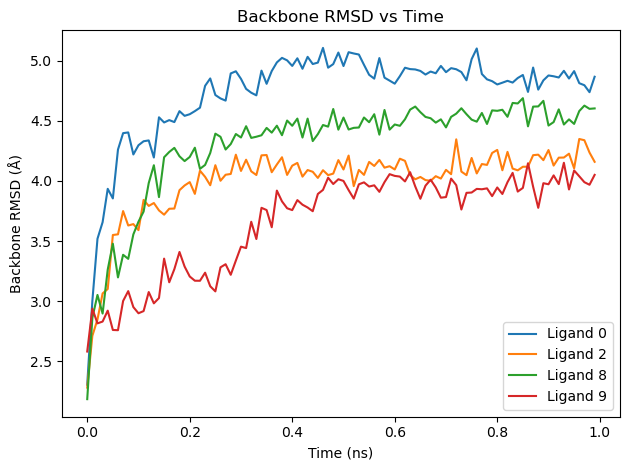

In [8]:
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
import matplotlib.pyplot as plt
import numpy as np
import glob

frame_dt_ps = 10.0    # time between saved frames (ps/frame)

LABELS = {
    '0ED'     : 'Ligand 0',
    '3342298' : 'Ligand 2',
    '71749231': 'Ligand 8',
    '9552079' : 'Ligand 9',
}

plt.figure

for lig_name in [s.name for s in systems]:    # code to iterate through md_results folder for every ligand
    structure_path = glob.glob(f'md_results/{lig_name}/shared_*SimulationUnit*_attempt_0/minimized.pdb')[0]
    trajectory_path = glob.glob(f'md_results/{lig_name}/shared_*SimulationUnit*_attempt_0/simulation.xtc')[0]

    u   = mda.Universe(structure_path, trajectory_path)
    n_frames = len(u.trajectory)
    t_ns = np.arange(n_frames) * frame_dt_ps / 1000.0

    ref = mda.Universe(structure_path)
    align.AlignTraj(u, ref, select="protein and backbone", in_memory=True).run()

    R = rms.RMSD(u, ref, select="protein and backbone").run()
    rmsd = R.results.rmsd[:, 2]

    stem  = lig_name.split('_1cgl')[0]
    label = LABELS.get(stem, stem)

    plt.plot(t_ns, rmsd, lw=1.5, label=label)
    print(f'{label}:  mean = {rmsd.mean()} Å  max = {rmsd.max()} Å')

plt.xlabel("Time (ns)")
plt.ylabel("Backbone RMSD (Å)")
plt.title("Backbone RMSD vs Time")
plt.legend()
plt.tight_layout()
plt.savefig("rmsd.png")
plt.show()

Heavily inspired by and built around Open Free Energy Notebook: Running a Molecular Dynamics (MD) simulation of a protein-ligand complex, Lab 2: Molecular Dynamics of Proteins (OpenMM)(University of California, Berkeley - Spring 2026 - ME 120/292A), and Lab 3B: Post-processing and Analysis of Molecular Dynamics Trajectories (University of California, Berkeley - Spring 2026 - ME 120/292A)